In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')

from utils import *


manifold = Hypersphere(1)
manifold_type = 'S1'

# Set Parameters

In [6]:
n_samples = 1000
sigma2 = .1

# prior param
num_modes = 3
tau2 = 0.05
G = G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 

# for empirical density estimation
M = 5
rho = 0.5
# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.01


In [7]:
Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
delta = denoiser(manifold_type, X, M, rho, sigma2, X)

oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, G )

oracle_delta_B = oracle_bayes__kernel(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, G )


loss_N = (manifold.metric.dist_broadcast(X, Theta).ravel()**2).mean()
loss_T = (manifold.metric.dist_broadcast(delta, Theta).ravel()**2).mean() 
loss_oracle_T = (manifold.metric.dist_broadcast(oracle_delta_T, Theta).ravel()**2).mean()
loss_oracle_B = (manifold.metric.dist_broadcast(oracle_delta_B, Theta).ravel()**2).mean()

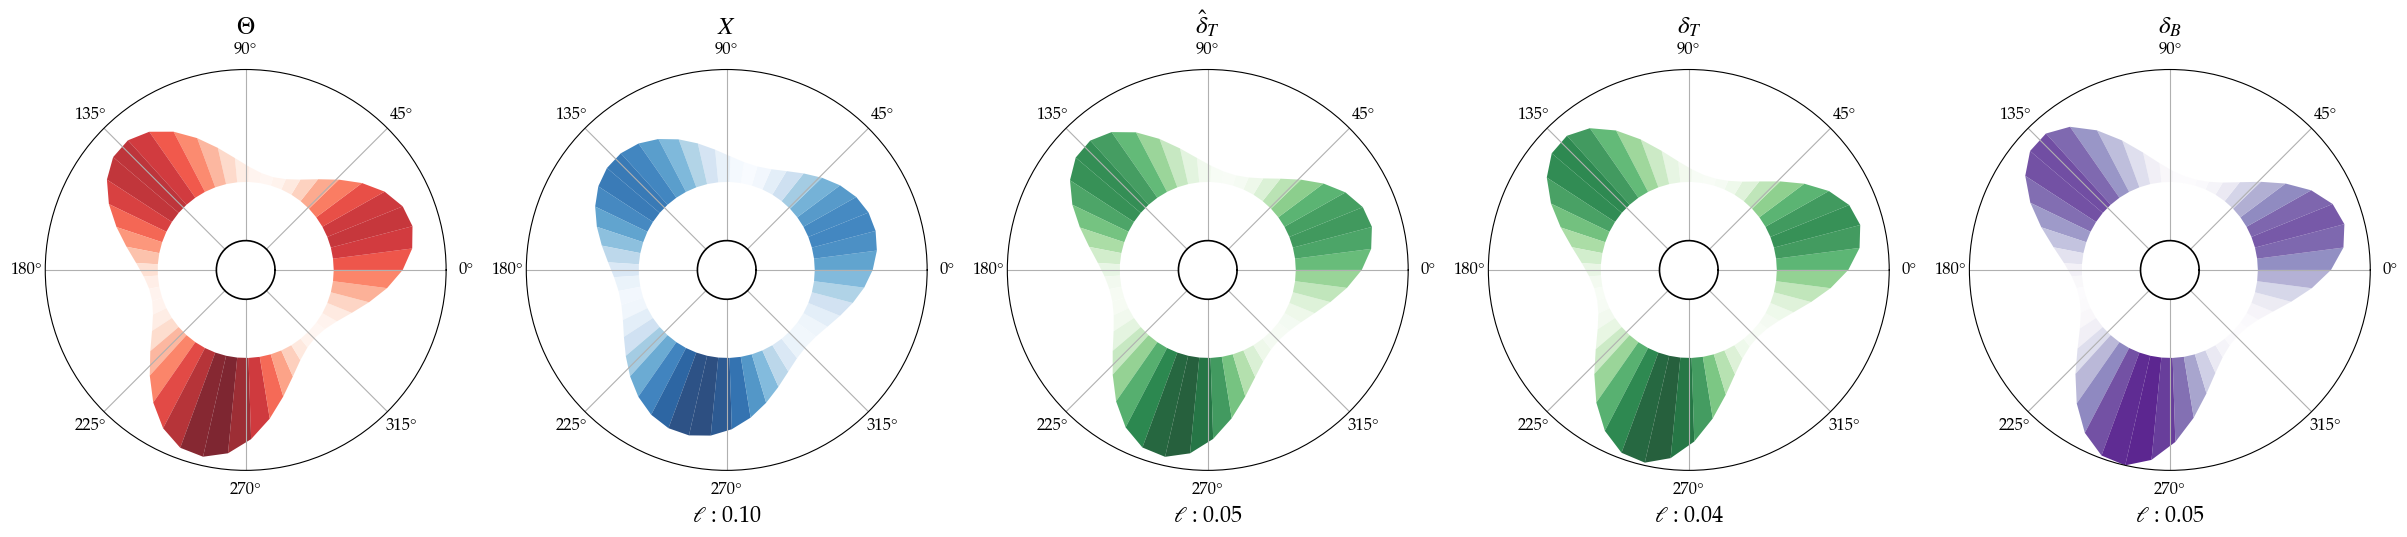

In [8]:
if True:
    fig, axs = plt.subplots(1, 5, figsize=(30, 10), subplot_kw={'polar': True}, sharey=True)

    size = 5.5; jitter_std = 5e-2; alpha = .2
    for ax, data, color in zip(axs, [Theta, X, delta, oracle_delta_T, oracle_delta_B], ['C3', 'C0', 'C2', 'C2', 'C4']):
        S1scatter(data, ax, color, alpha, size, jitter_std)

    nbins, kappa, fscale, bottom, top, disk_r = 50, 8, 1, .3, .5, 0.1
    for ax, data, color in zip(axs, [Theta, X, delta, oracle_delta_T, oracle_delta_B], ['Reds', 'Blues', 'Greens', 'Greens', 'Purples']):
        ax.set_ylim(0,1)
        S1_smooth_histogram(data, ax, color, nbins, kappa, fscale, bottom, top, disk_r)
        # S1_histogram(Theta, nbins, axs[0], 'Reds', .5)

    for ax, title, loss in zip(axs,['$\Theta$', '$X$', '$\hat\delta_T$', '$\delta_T$', '$\delta_B$'],[None, loss_N, loss_T, loss_oracle_T, loss_oracle_B],):
        ax.set_title(title, fontsize=18)
        if title != '$\Theta$':
            ax.set_xlabel(rf'$\ell$ : {loss:.2f}', fontsize=16)

    plt.savefig('denoising_S1.png', bbox_inches='tight')
    plt.show()


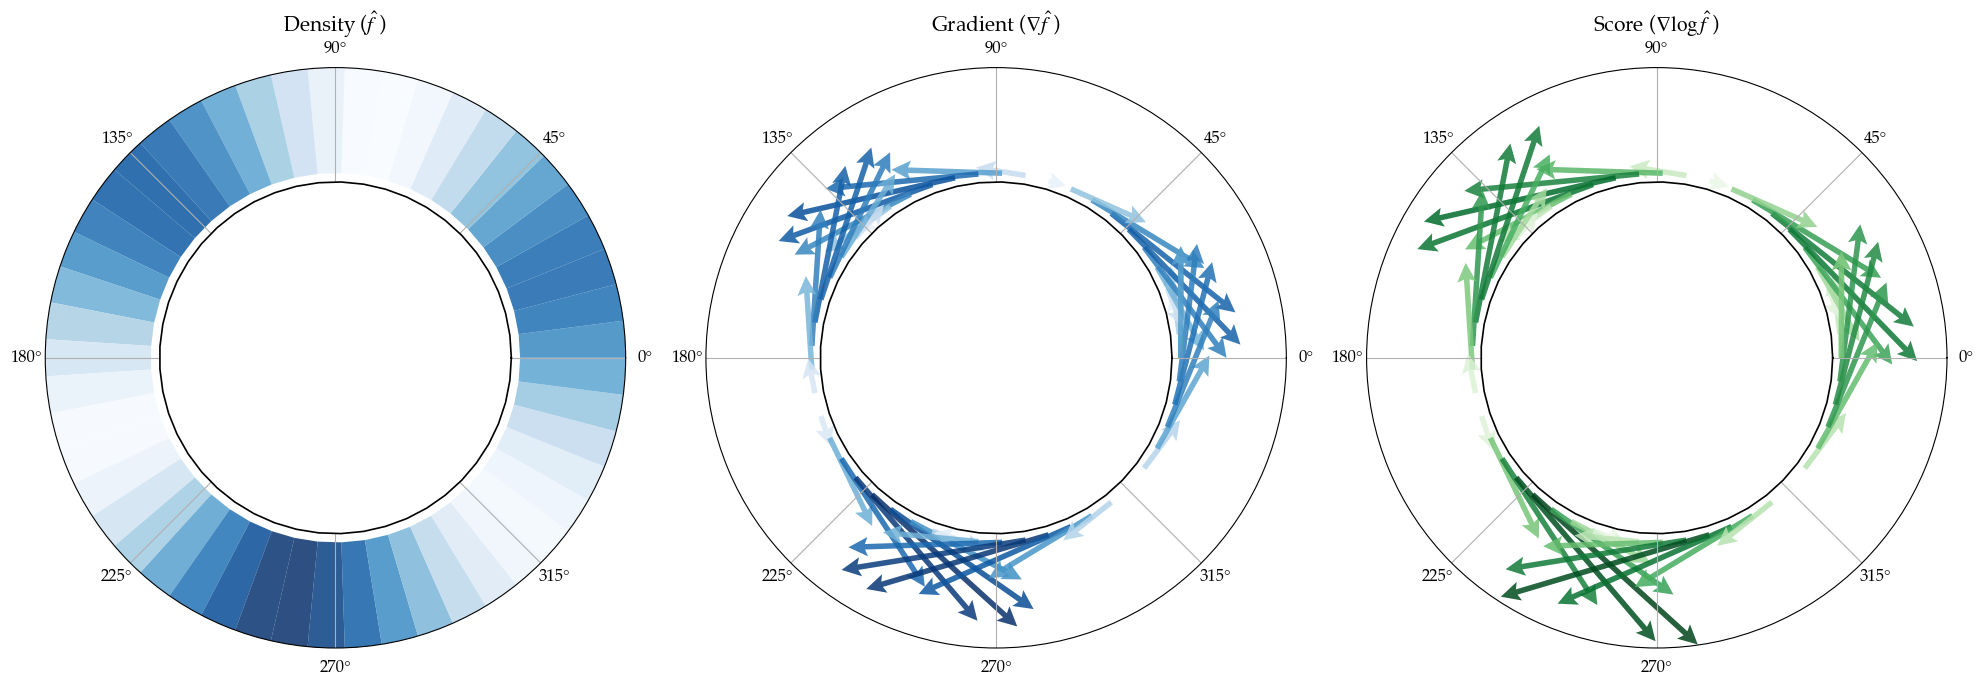

In [10]:
if True:
    f_scale = 0.3
    bottom = 0.105
    top = .5
    disk_r = 0.1

    fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
    grid_I = np.linspace(0, 2*np.pi, 50)
    grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    _, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)
    # ---------- DENSITY ---------------------------------------------------------------------------
    hat_pos_f = np.maximum(hat_f, 0)
    normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
    verts = [[
            (grid_I[i], bottom),
            # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
            (grid_I[i],top), (grid_I[i+1], bottom + top),
            (grid_I[i+1], bottom)
        ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
    poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                        alpha=0.85, edgecolors='none')
    axs[0].add_collection(poly)
    axs[0].set_title('Density ($\hat f$)', fontsize=15)
    # ---------- GRADIENT ---------------------------------------------------------------------------
    axs[1].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_grad_f[:, 0],          
        hat_grad_f[:, 1],          
        np.linalg.norm(hat_grad_f, axis=1),                 
        scale=4,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Blues',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)
    # ---------- SCORE ---------------------------------------------------------------------------
    hat_score = hat_grad_f /  np.maximum(hat_f.reshape(-1, 1), rho)
    axs[2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_score[:, 0],          
        hat_score[:, 1],          
        np.linalg.norm(hat_score, axis=1),                 
        scale=7,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)
    # -------------------------------------------------------------------------------------
    for ax in axs: 
        ax.set_ylim(0, bottom + f_scale*.2)  
        ax.set_yticks([])
        ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
    plt.tight_layout()
    plt.show()